In [1]:
# imports 
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map
from py_mods.src.SCF.scf_utils import _diagonalize_gram,  count_degen2
import matplotlib.pyplot as plt

from pathlib import Path

from pyscf.tools import molden

In [2]:
basis_names = [
    "aug-cc-pv5z",
]

cc_basis = basis_names[0:9]

In [5]:

print(f'Calculating energy with aug-cc-pv5z basis set')

pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"aug-cc-pv5z",
}

mol = gto.M(**pyscf_args)
mol.verbose = 0

mf = scf.RHF(mol)

e_He = mf.kernel()
e_elec = mf.energy_elec()

mymp = mp.RMP2(mf).run()  # this is UMP2

# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
# RHF_cxt.conv_start = 30
RHF_cxt.conv_type = None
# RHF_cxt.threshold = 1e-8

RHF_res = CS_RHF(RHF_cxt)
RHF_res.R_munu = RHF_res.R_munu.real

# enforce pyscf mo energies and coefficients
# RHF_res.R_munu = mf.mo_coeff
# RHF_res.e_orb = mf.mo_energy

mp_results = CS_MP2(RHF_res)

abs_error = (mymp.e_tot - mp_results.E_MP2)
rel_error = (np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

max_eorb_diff = max(abs(RHF_res.e_orb - mf.mo_energy))
print('Max orbital energy error:', max_eorb_diff)


Calculating energy with aug-cc-pv5z basis set
Max orbital energy error: 1.3600092785281959e-07


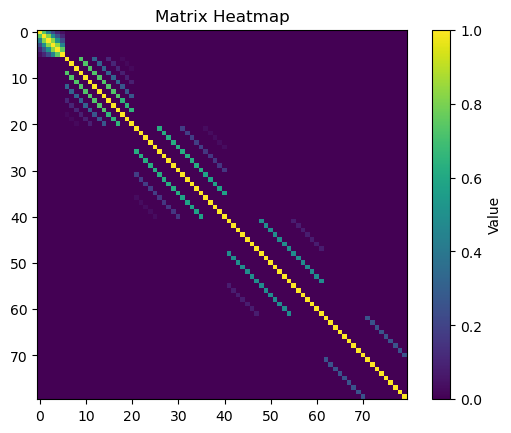

In [9]:
plot_map(RHF_res.context.S)

In [14]:
e_values, evectors = np.linalg.eigh(RHF_res.context.S)

In [15]:
print(e_values)

[0.01568051 0.05447167 0.05447167 0.05447167 0.07475905 0.15289035
 0.15289035 0.15289035 0.15289035 0.15289035 0.21328016 0.21328016
 0.21328016 0.2549182  0.34741713 0.34741713 0.34741713 0.34741713
 0.34741713 0.34741713 0.34741713 0.49981151 0.49981151 0.49981151
 0.49981151 0.49981151 0.62461645 0.62461645 0.62461645 0.67434374
 0.74479731 0.74479731 0.74479731 0.74479731 0.74479731 0.74479731
 0.74479731 0.74479731 0.74479731 0.91899219 0.91899219 0.91899219
 0.91899219 0.91899219 0.91899219 0.91899219 1.19034338 1.19034338
 1.19034338 1.19034338 1.19034338 1.25520269 1.25520269 1.25520269
 1.25520269 1.25520269 1.25520269 1.25520269 1.25520269 1.25520269
 1.43765422 1.43765422 1.43765422 1.59520317 1.73359068 1.73359068
 1.73359068 1.73359068 1.73359068 1.73359068 1.73359068 2.15695476
 2.15695476 2.15695476 2.15695476 2.15695476 2.6699775  2.6699775
 2.6699775  3.38509535]
